# FinRAG Fact Table Overview

Quick EDA/summary notebook for `finrag_fact_sentences.parquet` - the sentence-level fact table.

This folder (`DataPipeline/analytics/`) is meant to hold future notebooks for
fact tables, incremental batch tables, dimension tables, or ad-hoc development-stage EDA -
not just this one snapshot. Add new notebooks here rather than scattering them elsewhere.

Generated: 2026-07-27, after the edgartools-based rebuild that took the collection from
21 to 25 companies (UnitedHealth Group, Northrop Grumman, Caterpillar, T-Mobile US added)
and fully replaced Alphabet's history with a clean edgartools pull.

In [1]:
import polars as pl
import matplotlib.pyplot as plt

pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(60)

FACT_PATH = "../data_cache/stage1_facts/finrag_fact_sentences.parquet"
DIM_PATH = "../data_cache/dimensions/finrag_dim_companies_25.parquet"

fact = pl.read_parquet(FACT_PATH)
dim = pl.read_parquet(DIM_PATH)

print(f"Fact table: {fact.height:,} rows, {len(fact.columns)} columns")
print(f"Distinct companies: {fact['cik_int'].n_unique()}")
print(f"Distinct sentenceIDs == rows: {fact['sentenceID'].n_unique() == fact.height}")


Fact table: 614,910 rows, 24 columns
Distinct companies: 25
Distinct sentenceIDs == rows: True


## Company coverage: rows, year span, and tier

In [2]:
coverage = (
    fact.group_by("cik_int")
    .agg(
        pl.col("name").first().alias("name"),
        pl.len().alias("n_rows"),
        pl.col("report_year").min().alias("min_year"),
        pl.col("report_year").max().alias("max_year"),
        pl.col("report_year").n_unique().alias("n_years"),
    )
    .join(dim.select(["cik_int", "ticker", "tier"]), on="cik_int", how="left")
    .sort("cik_int")
)
coverage


cik_int,name,n_rows,min_year,max_year,n_years,ticker,tier
i32,str,u32,i64,i64,u32,str,str
18230,"""CATERPILLAR INC""",24389,2006,2025,18,"""CAT""","""TIER_EXPANSION_25"""
34088,"""EXXON MOBIL CORP""",15672,2006,2025,20,"""XOM""","""sp500_large"""
59478,"""ELI LILLY & Co""",22136,2006,2025,20,"""LLY""","""sp500_large"""
104169,"""Walmart Inc.""",11941,2006,2025,20,"""WMT""","""sp500_large"""
200406,"""JOHNSON & JOHNSON""",15981,2007,2025,14,"""JNJ""","""sp500_large"""
320193,"""Apple Inc.""",14133,2006,2025,20,"""AAPL""","""sp500_mega"""
731766,"""UNITEDHEALTH GROUP INC""",28104,2006,2025,20,"""UNH""","""TIER_EXPANSION_25"""
789019,"""MICROSOFT CORP""",20766,2006,2025,20,"""MSFT""","""sp500_mega"""
813762,"""ICAHN ENTERPRISES L.P.""",39299,2006,2025,20,"""IEP""","""notable_tier1"""


## Row provenance (load_method) - shows the mix of historical batches vs. the new edgartools pipeline

In [3]:
fact.group_by("load_method").agg(
    pl.len().alias("n_rows"),
    pl.col("cik_int").n_unique().alias("n_companies"),
    pl.col("report_year").min().alias("min_year"),
    pl.col("report_year").max().alias("max_year"),
).sort("load_method")


load_method,n_rows,n_companies,min_year,max_year
str,u32,u32,i64,i64
"""edgartools_incremental""",170407,25,2006,2025
"""extract_and_convert""",188085,20,2020,2024
"""stratified_sampling""",256418,20,2006,2020


## Temporal bin distribution

In [4]:
temporal = fact.group_by("temporal_bin").agg(pl.len().alias("n_rows")).sort("temporal_bin")
temporal


temporal_bin,n_rows
str,u32
"""bin_2006_2009""",67194
"""bin_2010_2015""",96536
"""bin_2016_2020""",218691
"""bin_2021_2025""",232489


## Section coverage (which 10-K items contribute the most sentences)

In [5]:
section_cov = (
    fact.group_by(["section_ID", "section_name"])
    .agg(pl.len().alias("n_sentences"))
    .sort("section_ID")
)
section_cov


section_ID,section_name,n_sentences
i64,str,u32
0,"""ITEM_1""",81529
1,"""ITEM_1A""",112772
2,"""ITEM_1B""",1175
3,"""ITEM_2""",6608
4,"""ITEM_3""",5185
5,"""ITEM_4""",3272
6,"""ITEM_5""",5193
7,"""ITEM_6""",1619
8,"""ITEM_7""",126287


## Feature-flag coverage (has_numbers / has_comparison / likely_kpi) - null rate reflects older batches that never computed these

In [6]:
for col in ["has_numbers", "has_comparison", "likely_kpi"]:
    vc = fact[col].value_counts().sort(col)
    print(f"--- {col} ---")
    print(vc)
    print()


--- has_numbers ---
shape: (3, 2)
┌─────────────┬────────┐
│ has_numbers ┆ count  │
│ ---         ┆ ---    │
│ bool        ┆ u32    │
╞═════════════╪════════╡
│ null        ┆ 188085 │
│ false       ┆ 319755 │
│ true        ┆ 107070 │
└─────────────┴────────┘

--- has_comparison ---
shape: (3, 2)
┌────────────────┬────────┐
│ has_comparison ┆ count  │
│ ---            ┆ ---    │
│ bool           ┆ u32    │
╞════════════════╪════════╡
│ null           ┆ 188085 │
│ false          ┆ 392148 │
│ true           ┆ 34677  │
└────────────────┴────────┘

--- likely_kpi ---
shape: (3, 2)
┌────────────┬────────┐
│ likely_kpi ┆ count  │
│ ---        ┆ ---    │
│ bool       ┆ u32    │
╞════════════╪════════╡
│ null       ┆ 188085 │
│ false      ┆ 355086 │
│ true       ┆ 71739  │
└────────────┴────────┘



## Sentences per company (bar chart)

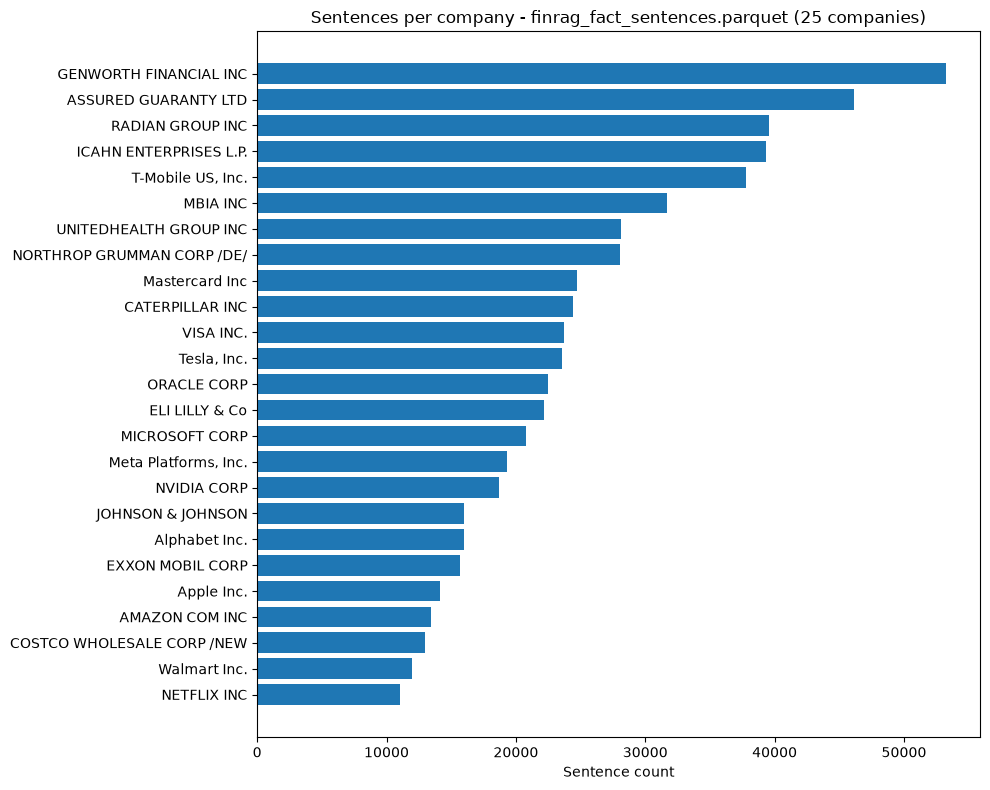

In [7]:
per_company = (
    fact.group_by(["cik_int"])
    .agg(pl.col("name").first().alias("name"), pl.len().alias("n_rows"))
    .sort("n_rows", descending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(per_company["name"].to_list()[::-1], per_company["n_rows"].to_list()[::-1])
ax.set_xlabel("Sentence count")
ax.set_title("Sentences per company - finrag_fact_sentences.parquet (25 companies)")
plt.tight_layout()
plt.show()


## Sanity checks

In [8]:
problems = []
for col in ["cik_int", "docID", "sentenceID", "sentence", "report_year"]:
    n = fact[col].null_count()
    if n:
        problems.append(f"{col}: {n} nulls")

if fact["sentenceID"].n_unique() != fact.height:
    problems.append("sentenceID not unique")

print("Problems found:" if problems else "No problems found - fact table looks clean.")
for p in problems:
    print(" -", p)


No problems found - fact table looks clean.
